In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [ ]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (1470, 35)


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (1470, 35)

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   ob

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Series([], dtype: int64)


In [ ]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [ ]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (1470, 35)


In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns

outlier_summary = {}

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

outlier_df = pd.DataFrame(
    list(outlier_summary.items()),
    columns=['Column', 'Number_of_Outliers']
)

display(outlier_df)

,Column,Number_of_Outliers
0,Age,0
1,DailyRate,0
2,DistanceFromHome,0
3,Education,0
4,EmployeeCount,0
5,EmployeeNumber,0
6,EnvironmentSatisfaction,0
7,HourlyRate,0
8,JobInvolvement,0
9,JobLevel,0


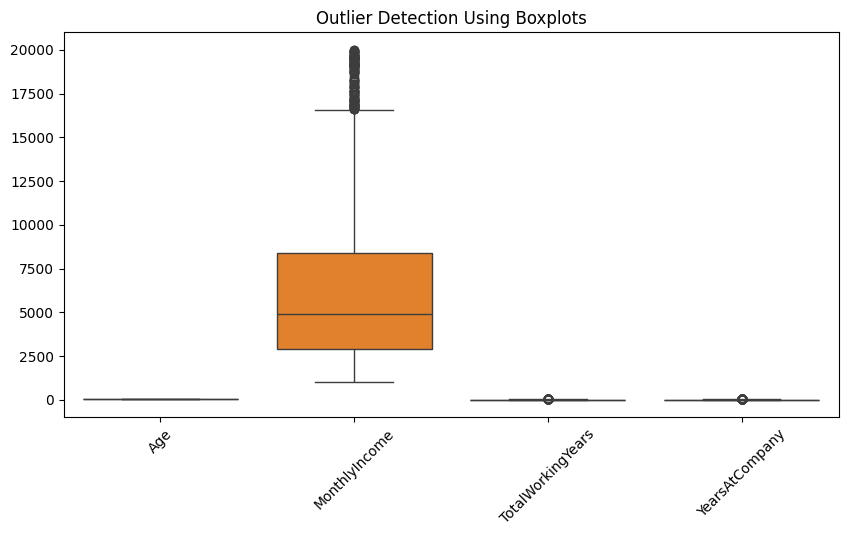

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany']])
plt.title('Outlier Detection Using Boxplots')
plt.xticks(rotation=45)
plt.show()

In [ ]:
outlier_columns = [
    'Age',
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager',
    'NumCompaniesWorked',
    'DistanceFromHome'
]

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier handling completed successfully.")

Outlier handling completed successfully.


In [ ]:
for column in df.columns:
    print(column, ":", df[column].nunique())

Age : 43
Attrition : 2
BusinessTravel : 3
DailyRate : 886
Department : 3
DistanceFromHome : 29
Education : 5
EducationField : 6
EmployeeCount : 1
EmployeeNumber : 1470
EnvironmentSatisfaction : 4
Gender : 2
HourlyRate : 71
JobInvolvement : 4
JobLevel : 5
JobRole : 9
JobSatisfaction : 4
MaritalStatus : 3
MonthlyIncome : 1238
MonthlyRate : 1427
NumCompaniesWorked : 10
Over18 : 1
OverTime : 2
PercentSalaryHike : 15
PerformanceRating : 2
RelationshipSatisfaction : 4
StandardHours : 1
StockOptionLevel : 4
TotalWorkingYears : 30
TrainingTimesLastYear : 7
WorkLifeBalance : 4
YearsAtCompany : 19
YearsInCurrentRole : 16
YearsSinceLastPromotion : 9
YearsWithCurrManager : 16


In [ ]:
constant_columns = [
    column for column in df.columns
    if df[column].nunique() <= 1
]

print("Constant Columns:", constant_columns)

df = df.drop(columns=constant_columns)

print("Dataset Shape After Removing Constant Columns:", df.shape)

Constant Columns: ['EmployeeCount', 'Over18', 'StandardHours']
Dataset Shape After Removing Constant Columns: (1470, 32)


In [ ]:
if 'EmployeeNumber' in df.columns:
    df = df.drop(columns=['EmployeeNumber'])

print("Updated Dataset Shape:", df.shape)

Updated Dataset Shape: (1470, 31)


In [ ]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [ ]:
label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8.0,0,1,6,4.0,0.0,5.0
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10.0,3,3,10,7.0,1.0,7.0
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7.0,3,3,0,0.0,0.0,0.0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8.0,3,3,8,7.0,3.0,0.0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6.0,3,3,2,2.0,2.0,2.0


In [ ]:
df['IncomePerYearExperience'] = (
    df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
)

In [ ]:
df['PromotionDelayRatio'] = (
    df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
)

In [ ]:
df['CareerStabilityRatio'] = (
    df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
)

In [ ]:
df['ManagerStabilityRatio'] = (
    df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)
)

In [ ]:
df['IncomePerJobLevel'] = (
    df['MonthlyIncome'] / (df['JobLevel'] + 1)
)

In [ ]:
df[[
    'IncomePerYearExperience',
    'PromotionDelayRatio',
    'CareerStabilityRatio',
    'ManagerStabilityRatio',
    'IncomePerJobLevel'
]].head()

,IncomePerYearExperience,PromotionDelayRatio,CareerStabilityRatio,ManagerStabilityRatio,IncomePerJobLevel
0,665.888889,0.000000,0.666667,0.714286,1997.666667
1,466.363636,0.090909,0.909091,0.636364,1710.000000
2,261.250000,0.000000,0.000000,0.000000,1045.000000
3,323.222222,0.333333,0.888889,0.000000,1454.500000
4,495.428571,0.666667,0.285714,0.666667,1734.000000


In [ ]:
target_column = 'Attrition'

numerical_columns = [
    column for column in df.select_dtypes(include=np.number).columns
    if column != target_column
]

In [ ]:
scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

print("Numerical features scaled successfully.")

Numerical features scaled successfully.


In [ ]:
# Reload original dataset for pipeline demonstration
raw_df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Remove ID and constant columns
raw_df = raw_df.drop(
    columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'],
    errors='ignore'
)

X = raw_df.drop('Attrition', axis=1)
y = raw_df['Attrition']

In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(include='object').columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


In [ ]:
X_processed = preprocessor.fit_transform(X)

print("Original Shape:", X.shape)
print("Processed Data Shape:", X_processed.shape)

Original Shape: (1470, 30)
Processed Data Shape: (1470, 51)


In [ ]:
print("Final Dataset Shape:", df.shape)

display(df.head())

Final Dataset Shape: (1470, 36)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomePerYearExperience,PromotionDelayRatio,CareerStabilityRatio,ManagerStabilityRatio,IncomePerJobLevel
0,0.446350,1,0.590048,0.742527,1.401512,-1.010909,-0.891688,-0.937414,-0.660531,-1.224745,...,-2.493820,-0.123832,-0.058474,-0.776139,0.253823,0.288283,-0.888468,0.350545,0.880164,0.155245
1,1.322365,0,-0.913194,-1.297775,-0.493817,-0.147150,-1.868426,-0.937414,0.254625,0.816497,...,0.338096,0.678078,0.785616,-0.372486,0.822605,-0.420592,-0.532727,1.235428,0.597616,-0.277930
2,0.008343,1,0.590048,1.414363,-0.493817,-0.887515,-0.891688,1.316673,1.169781,0.816497,...,0.338096,-1.326697,-1.183926,-0.776139,-1.168130,-1.149322,-0.888468,-2.082881,-1.709858,-1.279303
3,-0.429664,0,-0.913194,1.461466,-0.493817,-0.764121,1.061787,-0.937414,1.169781,-1.224745,...,0.338096,0.277123,0.785616,0.434819,-1.168130,-0.929146,0.415917,1.161687,-1.709858,-0.662668
4,-1.086676,0,0.590048,-0.524295,-0.493817,-0.887515,-1.868426,0.565311,-1.575686,0.816497,...,0.338096,-0.925742,-0.621200,0.031166,-0.599348,-0.317330,1.720303,-1.039984,0.707496,-0.241791


In [ ]:
df.to_csv(
    'processed_employee_attrition_dataset.csv',
    index=False
)

print("Processed dataset exported successfully!")

Processed dataset exported successfully!


In [ ]:
files.download('processed_employee_attrition_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("=" * 50)
print("ENTERPRISE DATA PREPARATION SUMMARY")
print("=" * 50)

print("Original Dataset Rows: 1470")
print("Original Dataset Columns: 35")
print("Missing Values:", 0)
print("Duplicate Records:", 0)
print("Final Dataset Shape:", df.shape)
print("Number of Derived Features:", 5)
print("Status: Data Preparation Completed Successfully")
print("=" * 50)

ENTERPRISE DATA PREPARATION SUMMARY
Original Dataset Rows: 1470
Original Dataset Columns: 35
Missing Values: 0
Duplicate Records: 0
Final Dataset Shape: (1470, 36)
Number of Derived Features: 5
Status: Data Preparation Completed Successfully
